In [1]:
docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [23]:
from keras.datasets import imdb
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(oov_token='<nothing>')

In [25]:
tokenizer.fit_on_texts(docs)

In [26]:
len(tokenizer.word_index)

18

In [37]:
import numpy as np
np.max(sequences)

np.int32(18)

In [27]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[10, 2],
 [2, 2],
 [4, 4, 11],
 [3, 12, 3, 2, 3],
 [13, 14, 5, 6],
 [7, 7],
 [8, 8],
 [9, 9],
 [15, 16, 5, 6],
 [17, 18]]

In [28]:
from keras.utils import pad_sequences
sequences = pad_sequences(sequences,padding='post')
sequences

array([[10,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 4,  4, 11,  0,  0],
       [ 3, 12,  3,  2,  3],
       [13, 14,  5,  6,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [15, 16,  5,  6,  0],
       [17, 18,  0,  0,  0]], dtype=int32)

In [38]:
model = Sequential()

model.add(Embedding(input_dim=19,output_dim=2,input_shape=(5,)))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 5, 2)           │            38 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 38 (152.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile('adam','accuracy')

In [40]:
pred = model.predict(sequences)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[[ 0.02324798  0.01937796]
  [ 0.03099913  0.04329151]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413]]

 [[ 0.03099913  0.04329151]
  [ 0.03099913  0.04329151]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413]]

 [[-0.00267165 -0.02749311]
  [-0.00267165 -0.02749311]
  [-0.02229316  0.00584788]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413]]

 [[-0.01553823  0.04498651]
  [-0.03789295  0.04035771]
  [-0.01553823  0.04498651]
  [ 0.03099913  0.04329151]
  [-0.01553823  0.04498651]]

 [[ 0.02783454 -0.04572641]
  [-0.04483395  0.0102535 ]
  [-0.02763326 -0.00084345]
  [-0.03351549  0.03344532]
  [ 0.01274235  0.04608413]]

 [[ 0.01429267  0.03983818]
  [ 0.01429267  0.03983818]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413]]

 [[-0.01947552 -0.00531467]
  [-0.01947552 -0.00531467]
  [ 0.01274235  0.04608413]
  [ 0.01274235  0.04608413

In [61]:
(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=10000)

In [63]:
X_train = pad_sequences(X_train,padding='post',maxlen=50)
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [64]:
X_train.shape

(25000, 50)

In [65]:
model = Sequential()
model.add(Embedding(10000, output_dim=2, input_shape=(50,)))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 50, 2)          │        20,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,153 (82.63 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5980 - loss: 0.6329 - val_accuracy: 0.7922 - val_loss: 0.4518
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8212 - loss: 0.4026 - val_accuracy: 0.8144 - val_loss: 0.4144
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8628 - loss: 0.3314 - val_accuracy: 0.8070 - val_loss: 0.4242
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8807 - loss: 0.2949 - val_accuracy: 0.8051 - val_loss: 0.4409
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8993 - loss: 0.2624 - val_accuracy: 0.8003 - val_loss: 0.4603


In [67]:
import matplotlib.pyplot as plt

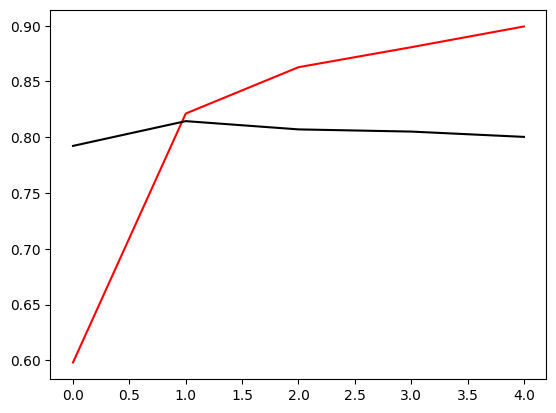

In [70]:
plt.plot(history.history['accuracy'],color='red',label='train_accuracy')
plt.plot(history.history['val_accuracy'],color='black',label='val_accuracy')